# Perception Stack - Notebook 02c: Optical Flow and Velocity via RAFT

This notebook runs Stage 4 of the Perception Stack pipeline.
RAFT-small is used to estimate per-object velocity vectors at two categories
of frame pairs per clip: the 3-frame window before each SAM 2 overlap event,
and the final 3-frame window (frames 124 to 127).
Flow is sampled within a 15x15 pixel window centered at the SAM 2 centroid
for each object of interest.

## Steps
- Mount Google Drive and define all constants and paths
- Install dependencies and load RAFT-small via torchvision
- Define all helper functions: frame extraction, RAFT tensor conversion,
  flow inference, SAM 2 NPZ loading, and centroid window velocity extraction
- Build frame pair lists for all 70 clips: pre-overlap pairs and final velocity pairs
- Run main RAFT inference loop across all 70 clips with per-clip checkpointing:
  for each frame pair, run RAFT and sample flow at object centroids
- Save per-clip velocity results as compressed `.npz` to Drive
- Generate optical flow arrow visualizations for the first 3 clips
- Preview assembled velocity context strings for 2 clips
- Report final Drive storage usage

---
> **Note:** This notebook is natively developed and run on Google Colab (A100 GPU required).
> If it does not render correctly in your viewer, please open it directly on Colab:
> [Open in Google Colab](<https://colab.research.google.com/drive/1Ppr8HChVEvBWy__U-107GlPQCJzbU_A2?usp=sharing>)

---
# Cell 1 - Drive mount, constants, paths

In [1]:
# ── Cell 1 — Mount Drive + Constants + Paths ───────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# ── CLEAR: Delete all NB02c outputs ────────────────────────────────────────
import os

BASE = "/content/drive/MyDrive/NEU - MS CS/4_SEM (Jan 2026)/CV/Projects/final_project"

# Clear RAFT npz files
raft_dir = os.path.join(BASE, "outputs/stage3_raft")
deleted = 0
for f in os.listdir(raft_dir):
    if f.startswith("stage3_raft_") and f.endswith(".npz"):
        os.remove(os.path.join(raft_dir, f))
        deleted += 1
print(f"Deleted {deleted} RAFT npz files")

# Clear NB02c figures
fig_dir = os.path.join(BASE, "figures")
deleted_figs = 0
for f in os.listdir(fig_dir):
    if f.startswith("02c_"):
        os.remove(os.path.join(fig_dir, f))
        deleted_figs += 1
print(f"Deleted {deleted_figs} NB02c figures")

print("NB02c slate cleared.")

Deleted 2 RAFT npz files
Deleted 2 NB02c figures
NB02c slate cleared.


In [3]:
import os
import json

# ── Constants ──────────────────────────────────────────────────────────────
NO_CLIPS  = 70     # change this one number to scale up

# ── Base path on Drive ─────────────────────────────────────────────────────
BASE        = "/content/drive/MyDrive/NEU - MS CS/4_SEM (Jan 2026)/CV/Projects/final_project"
CLIPS_DIR   = os.path.join(BASE, "data/clips")
ID_PATH     = os.path.join(BASE, "data/selected_clip_ids.json")
SAM2_DIR    = os.path.join(BASE, "outputs/stage1_sam2")
OUT_RAFT    = os.path.join(BASE, "outputs/stage3_raft")
FIGURES_DIR = os.path.join(BASE, "figures")

os.makedirs(OUT_RAFT, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

# ── Load selected clip IDs ─────────────────────────────────────────────────
with open(ID_PATH, 'r') as f:
    ALL_SELECTED_IDS = json.load(f)

SELECTED_IDS = ALL_SELECTED_IDS[:NO_CLIPS]
print(f"Drive mounted.")
print(f"Working with {NO_CLIPS} clips: {SELECTED_IDS}")

Drive mounted.
Working with 70 clips: [10001, 10002, 10003, 10004, 10005, 10006, 10007, 10008, 10009, 10010, 10011, 10012, 10013, 10014, 10015, 10016, 10017, 10018, 10019, 10020, 10021, 10022, 10023, 10024, 10025, 10026, 10027, 10028, 10029, 10030, 10031, 10032, 10033, 10034, 10035, 10036, 10037, 10038, 10039, 10040, 10041, 10042, 10043, 10044, 10045, 10046, 10047, 10048, 10049, 10050, 10051, 10052, 10053, 10054, 10055, 10056, 10057, 10058, 10059, 10060, 10061, 10062, 10063, 10064, 10065, 10066, 10067, 10068, 10069, 10070]


---
# Cell 2 - Install Dependencies

In [4]:
# ── Cell 2 — Install Dependencies ──────────────────────────────────────────
# torchvision: contains RAFT-small built in
# opencv: frame extraction from .mp4

!pip install -q torchvision opencv-python-headless

print("Dependencies installed.")

Dependencies installed.


---
# Cell 3 - Load RAFT-small Model

In [5]:
# ── Cell 3 — Load RAFT-small Model ─────────────────────────────────────────
import torch
import torchvision.models.optical_flow as of

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = of.raft_small(weights=of.Raft_Small_Weights.DEFAULT)
model = model.to(device)
model.eval()

print(f"RAFT-small loaded on: {device}")
print(f"VRAM used: {torch.cuda.memory_allocated()/1e9:.2f} GB")

Downloading: "https://download.pytorch.org/models/raft_small_C_T_V2-01064c6d.pth" to /root/.cache/torch/hub/checkpoints/raft_small_C_T_V2-01064c6d.pth


100%|██████████| 3.82M/3.82M [00:00<00:00, 44.7MB/s]


RAFT-small loaded on: cuda
VRAM used: 0.00 GB


---

# Cell 4 - Helper Functions

In [6]:
# ── Cell 4 — Helper Functions ───────────────────────────────────────────────
import cv2
import numpy as np
from PIL import Image

def extract_frame(vid_id, frame_idx):
    """Extract a single frame from .mp4, returns RGB numpy array (H, W, 3)."""
    clip_path = os.path.join(CLIPS_DIR, f"video_{vid_id:05d}.mp4")
    cap = cv2.VideoCapture(clip_path)
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
    ret, frame = cap.read()
    cap.release()
    if not ret:
        raise ValueError(f"Could not read frame {frame_idx} from clip {vid_id}")
    return cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

def frame_to_raft_tensor(frame_rgb):
    """
    Convert RGB numpy array to RAFT input tensor.
    RAFT expects: float32, shape (1, 3, H, W), values in [0, 255].
    """
    tensor = torch.from_numpy(frame_rgb).permute(2, 0, 1).float()
    return tensor.unsqueeze(0).to(device)

def run_raft(vid_id, frame_idx_a, frame_idx_b):
    """
    Run RAFT-small on two frames of a clip.
    Returns flow as numpy array of shape (2, H, W):
        flow[0] = dx field (horizontal motion, positive = rightward)
        flow[1] = dy field (vertical motion, positive = downward)
    """
    frame_a = extract_frame(vid_id, frame_idx_a)
    frame_b = extract_frame(vid_id, frame_idx_b)

    tensor_a = frame_to_raft_tensor(frame_a)
    tensor_b = frame_to_raft_tensor(frame_b)

    with torch.no_grad():
        flow_predictions = model(tensor_a, tensor_b)
        flow = flow_predictions[-1]  # last iteration = most refined

    return flow[0].cpu().numpy()  # (2, H, W)

def load_sam2_npz(vid_id):
    """Load SAM 2 NPZ for a clip."""
    npz_path = os.path.join(SAM2_DIR, f"stage1_sam2_{vid_id:05d}.npz")
    return np.load(npz_path, allow_pickle=True)

def get_mask_at_frame(npz, label, frame_idx):
    """
    Reconstruct boolean mask at a given frame from SAM 2 centroids and areas.
    Returns None if object not visible at that frame.
    Note: SAM2 NPZ stores centroids and areas, not raw masks.
    We use areas > 0 to check visibility, centroids for position.
    Since raw masks are not stored, we return centroid as fallback
    for flow sampling -- see get_object_velocity() below.
    """
    areas = npz[f"{label}__areas"]
    if areas[frame_idx] == 0:
        return None
    centroids = npz[f"{label}__centroids"]
    return centroids[frame_idx]  # (cx, cy)

def get_object_velocity(flow, npz, label, frame_idx):
    """
    Get velocity of one object at one frame using flow field.
    Since raw SAM 2 masks are not saved (too large), we sample
    flow in a 15x15 pixel window around the object centroid.
    This approximates mask-averaging for small objects.
    Returns (dx, dy) or None if object not visible.
    """
    areas = npz[f"{label}__areas"]
    if areas[frame_idx] == 0:
        return None

    centroids = npz[f"{label}__centroids"]
    cx, cy = centroids[frame_idx]
    if np.isnan(cx) or np.isnan(cy):
        return None

    H, W = flow.shape[1], flow.shape[2]
    cx, cy = int(round(cx)), int(round(cy))

    # ── Sample in 15x15 window around centroid ─────────────────────────────
    half  = 7
    x1    = max(0, cx - half)
    x2    = min(W, cx + half + 1)
    y1    = max(0, cy - half)
    y2    = min(H, cy + half + 1)

    dx = float(flow[0, y1:y2, x1:x2].mean())
    dy = float(flow[1, y1:y2, x1:x2].mean())

    return round(dx, 4), round(dy, 4)

print("Helper functions defined.")

Helper functions defined.


---
# Cell 5 — Identify Frame Pairs to Run Per Clip

In [7]:
# ── Cell 5 — Identify Frame Pairs to Run Per Clip ──────────────────────────

def get_frame_pairs(vid_id, npz):
    """
    Build the list of frame pairs to run RAFT on for a clip.

    Two sources:
    1. Pre-overlap pairs: (overlap_frame - 1, overlap_frame)
       Only for the two objects involved in that overlap.
    2. Final pair: (126, 127) for all objects.

    Returns list of dicts:
    {
        'frame_a'  : int,
        'frame_b'  : int,
        'objects'  : [label, ...],  -- which objects to sample at this pair
        'tag'      : str            -- 'pre_overlap' or 'final'
    }
    """
    obj_labels     = list(npz['obj_labels'])
    overlap_obj_a  = list(npz['overlap_obj_a'])
    overlap_obj_b  = list(npz['overlap_obj_b'])
    overlap_frames = list(npz['overlap_frames'])

    pairs = []

    # ── Pre-overlap pairs ──────────────────────────────────────────────────
    for obj_a, obj_b, ov_frame in zip(overlap_obj_a, overlap_obj_b, overlap_frames):
        ov_frame = int(ov_frame)
        # if ov_frame < 1:
        if ov_frame < 3:
            continue  # can't go to frame -1
        pairs.append({
            # 'frame_a' : ov_frame - 1,
            'frame_a' : ov_frame - 3,
            'frame_b' : ov_frame,
            'objects' : [str(obj_a), str(obj_b)],
            'tag'     : f"pre_overlap_{str(obj_a)}__{str(obj_b)}"
        })

    # ── Final pair ─────────────────────────────────────────────────────────
    pairs.append({
        # 'frame_a' : 126,
        'frame_a' : 124,
        'frame_b' : 127,
        'objects' : obj_labels,
        'tag'     : 'final'
    })

    return pairs

# ── Preview for 2 clips ─────────────────────────────────────────────────
for vid_id in SELECTED_IDS[:2]:
    npz   = load_sam2_npz(vid_id)
    pairs = get_frame_pairs(vid_id, npz)
    print(f"\nClip {vid_id} -- {len(pairs)} frame pairs:")
    for p in pairs:
        print(f"  [{p['tag'][:30]:30s}] frames ({p['frame_a']},{p['frame_b']}) "
              f"-- objects: {p['objects']}")

print("\nCell 5 complete.")


Clip 10001 -- 3 frame pairs:
  [pre_overlap_gray_metal_cube__g] frames (96,99) -- objects: ['gray_metal_cube', 'green_metal_sphere']
  [pre_overlap_green_metal_sphere] frames (89,92) -- objects: ['green_metal_sphere', 'yellow_metal_cylinder']
  [final                         ] frames (124,127) -- objects: [np.str_('brown_metal_cube'), np.str_('gray_metal_cube'), np.str_('green_metal_sphere'), np.str_('yellow_rubber_sphere'), np.str_('yellow_metal_cylinder')]

Clip 10002 -- 6 frame pairs:
  [pre_overlap_blue_metal_cylinde] frames (56,59) -- objects: ['blue_metal_cylinder', 'green_metal_cube']
  [pre_overlap_cyan_rubber_cube__] frames (51,54) -- objects: ['cyan_rubber_cube', 'green_metal_cube']
  [pre_overlap_gray_metal_sphere_] frames (48,51) -- objects: ['gray_metal_sphere', 'green_metal_cube']
  [pre_overlap_gray_metal_sphere_] frames (103,106) -- objects: ['gray_metal_sphere', 'gray_rubber_sphere']
  [pre_overlap_green_metal_cube__] frames (112,115) -- objects: ['green_metal_cube', 

---
# Cell 6 — Main Inference Loop with Checkpointing

In [9]:
# ── Cell 6 — Main Inference Loop with Checkpointing ────────────────────────
import time

def process_clip(vid_id):
    """
    Run RAFT on all frame pairs for a clip.
    Returns dict of results to save as NPZ.
    """
    npz   = load_sam2_npz(vid_id)
    pairs = get_frame_pairs(vid_id, npz)

    save_dict = {}
    clip_start = time.time()

    for pair in pairs:
        frame_a = pair['frame_a']
        frame_b = pair['frame_b']
        tag     = pair['tag']
        objects = pair['objects']

        # ── Run RAFT on this frame pair ────────────────────────────────────
        flow = run_raft(vid_id, frame_a, frame_b)

        # ── Sample velocity for each object ────────────────────────────────
        for label in objects:
            result = get_object_velocity(flow, npz, label, frame_a)
            if result is None:
                print(f"  [{tag}] {label}: not visible at frame {frame_a}, skipping.")
                continue
            dx, dy = result
            key_dx = f"{tag}__{label}__dx"
            key_dy = f"{tag}__{label}__dy"
            save_dict[key_dx] = np.array([dx])
            save_dict[key_dy] = np.array([dy])
            print(f"  [{tag[:25]:25s}] {label}: dx={dx:+.3f}, dy={dy:+.3f}")

    save_dict['obj_labels'] = npz['obj_labels']
    clip_runtime = round(time.time() - clip_start, 2)
    print(f"  Clip {vid_id} done in {clip_runtime}s")
    return save_dict

In [10]:
# ── Main loop ──────────────────────────────────────────────────────────────
for vid_id in SELECTED_IDS:
    out_path = os.path.join(OUT_RAFT, f"stage3_raft_{vid_id:05d}.npz")

    if os.path.exists(out_path):
        print(f"Clip {vid_id}: already processed, skipping.")
        continue

    print(f"\nProcessing clip {vid_id}...")
    save_dict = process_clip(vid_id)

    np.savez_compressed(out_path, **save_dict)
    print(f"  Saved -> {out_path}")

print("\nCell 6 complete.")


Processing clip 10001...
  [pre_overlap_gray_metal_cu] gray_metal_cube: dx=+5.531, dy=-1.765
  [pre_overlap_gray_metal_cu] green_metal_sphere: dx=+4.942, dy=-1.899
  [pre_overlap_green_metal_s] green_metal_sphere: dx=+7.828, dy=-1.045
  [pre_overlap_green_metal_s] yellow_metal_cylinder: dx=+0.993, dy=+3.191
  [final                    ] brown_metal_cube: dx=-9.736, dy=+1.977
  [final                    ] gray_metal_cube: dx=+5.228, dy=-0.755
  [final                    ] green_metal_sphere: dx=+5.365, dy=+0.208
  [final                    ] yellow_rubber_sphere: dx=+2.961, dy=+3.531
  [final                    ] yellow_metal_cylinder: dx=+1.866, dy=-0.705
  Clip 10001 done in 2.56s
  Saved -> /content/drive/MyDrive/NEU - MS CS/4_SEM (Jan 2026)/CV/Projects/final_project/outputs/stage3_raft/stage3_raft_10001.npz

Processing clip 10002...
  [pre_overlap_blue_metal_cy] blue_metal_cylinder: dx=-3.916, dy=+1.079
  [pre_overlap_blue_metal_cy] green_metal_cube: dx=+0.456, dy=-14.918
  [pre_ov

---
# Cell 7 — Flow Visualization

  brown_metal_cube: cx=338.6, cy=143.9, dx=-9.736, dy=1.977, arrow_end=(289.9, 153.8)
  gray_metal_cube: cx=398.3, cy=65.0, dx=5.228, dy=-0.755, arrow_end=(424.4, 61.2)
  green_metal_sphere: cx=455.7, cy=66.7, dx=5.365, dy=0.208, arrow_end=(482.6, 67.7)
  yellow_rubber_sphere: cx=341.7, cy=81.6, dx=2.961, dy=3.531, arrow_end=(356.5, 99.3)
  yellow_metal_cylinder: cx=436.3, cy=86.5, dx=1.866, dy=-0.705, arrow_end=(445.6, 83.0)


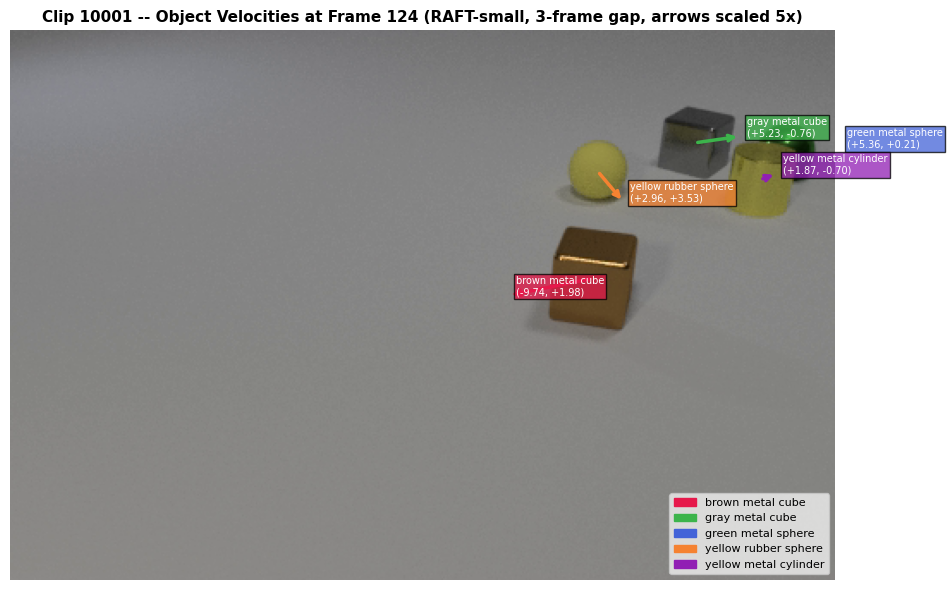

Saved -> /content/drive/MyDrive/NEU - MS CS/4_SEM (Jan 2026)/CV/Projects/final_project/figures/02c_flow_clip10001.jpg
  blue_metal_cylinder: cx=150.6, cy=54.8, dx=-1.912, dy=-1.350, arrow_end=(141.1, 48.0)
  brown_metal_cylinder: cx=415.2, cy=152.7, dx=0.052, dy=0.335, arrow_end=(415.5, 154.4)
  cyan_rubber_cube: cx=143.8, cy=121.3, dx=-0.837, dy=-0.055, arrow_end=(139.7, 121.0)
  gray_metal_sphere: cx=290.0, cy=82.5, dx=1.607, dy=-4.964, arrow_end=(298.1, 57.7)
  green_metal_cube: cx=248.4, cy=73.5, dx=0.212, dy=-0.004, arrow_end=(249.5, 73.5)
  gray_rubber_sphere: cx=245.6, cy=49.4, dx=-3.805, dy=-0.405, arrow_end=(226.6, 47.4)


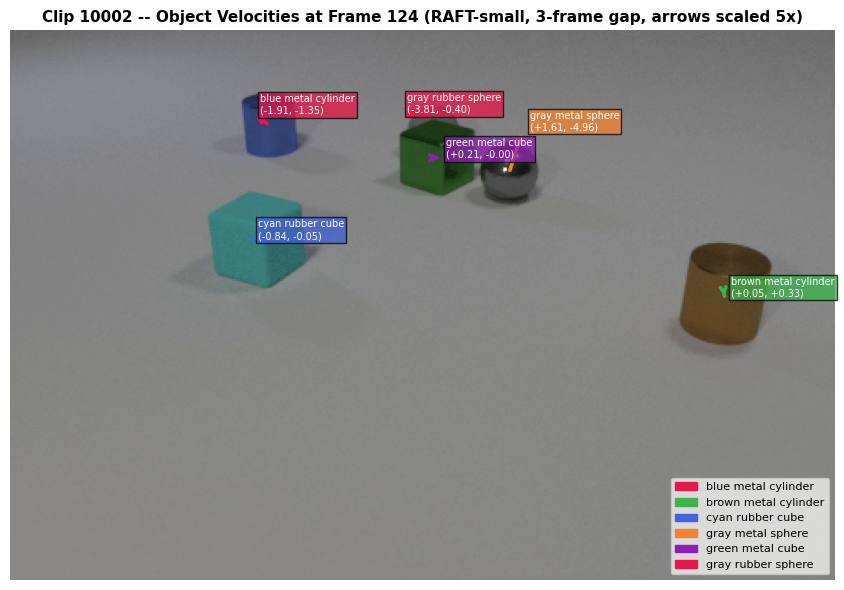

Saved -> /content/drive/MyDrive/NEU - MS CS/4_SEM (Jan 2026)/CV/Projects/final_project/figures/02c_flow_clip10002.jpg

Cell 7 complete.


In [11]:
# ── Cell 7 — Flow Visualization ────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def plot_flow_arrows(vid_id, frame_idx=124):
    """
    Plot frame 124 with final velocity arrows overlaid per object.
    Arrow direction = direction of motion.
    Arrow length scaled for visibility.
    """
    raft_npz  = np.load(os.path.join(OUT_RAFT, f"stage3_raft_{vid_id:05d}.npz"),
                        allow_pickle=True)
    sam2_npz  = load_sam2_npz(vid_id)
    obj_labels = [str(l) for l in sam2_npz['obj_labels']]

    frame_rgb = extract_frame(vid_id, frame_idx)

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.imshow(frame_rgb)
    ax.set_title(f"Clip {vid_id} -- Object Velocities at Frame {frame_idx} "
                 f"(RAFT-small, 3-frame gap, arrows scaled 5x)",
                 fontsize=11, fontweight='bold')
    ax.axis('off')

    colors = ['#e6194b', '#3cb44b', '#4363d8', '#f58231', '#911eb4']
    legend_patches = []
    scale = 5

    for i, label in enumerate(obj_labels):
        centroids = sam2_npz[f"{label}__centroids"]
        cx, cy    = centroids[frame_idx]
        if np.isnan(cx) or np.isnan(cy):
            continue

        key_dx = f"final__{label}__dx"
        key_dy = f"final__{label}__dy"
        if key_dx not in raft_npz or key_dy not in raft_npz:
            continue

        dx = float(raft_npz[key_dx][0])
        dy = float(raft_npz[key_dy][0])
        print(f"  {label}: cx={cx:.1f}, cy={cy:.1f}, dx={dx:.3f}, dy={dy:.3f}, arrow_end=({cx + dx*scale:.1f}, {cy + dy*scale:.1f})")
        color    = colors[i % len(colors)]
        readable = label.replace('_', ' ')

        # ── Arrow ──────────────────────────────────────────────────────────
        ax.annotate(
            '', xy=(cx + dx * scale, cy + dy * scale),
            xytext=(cx, cy),
            arrowprops=dict(arrowstyle='->', color=color, lw=2.5)
        )

        # ── Label ──────────────────────────────────────────────────────────
        ax.text(cx + dx * scale + 4, cy + dy * scale,
                f"{readable}\n({dx:+.2f}, {dy:+.2f})",
                fontsize=7, color='white',
                bbox=dict(facecolor=color, alpha=0.75, pad=1.5))

        legend_patches.append(mpatches.Patch(color=color, label=readable))

    ax.legend(handles=legend_patches, loc='lower right',
              fontsize=8, framealpha=0.7)

    plt.tight_layout()
    fig_path = os.path.join(FIGURES_DIR, f"02c_flow_clip{vid_id}.jpg")
    plt.savefig(fig_path, dpi=120, bbox_inches='tight')
    plt.show()
    plt.close()
    print(f"Saved -> {fig_path}")

for vid_id in SELECTED_IDS[:2]:
  if vid_id in SELECTED_IDS[:3]:
    plot_flow_arrows(vid_id)

print("\nCell 7 complete.")

---
# Cell 8 — Context String Preview

In [12]:
# ── Cell 8 — Context String Preview ───────────────────────────────────────
def build_velocity_context_string(vid_id):
    """
    Build the RAFT contribution to the context string for a clip.
    Two sections:
    1. Pre-overlap velocities (for each overlap pair's objects)
    2. Final velocities (all objects at frame 124-127)
    """
    raft_npz   = np.load(os.path.join(OUT_RAFT, f"stage3_raft_{vid_id:05d}.npz"),
                         allow_pickle=True)
    sam2_npz   = load_sam2_npz(vid_id)
    obj_labels = [str(l) for l in sam2_npz['obj_labels']]

    overlap_obj_a  = [str(x) for x in sam2_npz['overlap_obj_a']]
    overlap_obj_b  = [str(x) for x in sam2_npz['overlap_obj_b']]
    overlap_frames = [int(x) for x in sam2_npz['overlap_frames']]

    def direction_str(dx, dy):
        """Convert dx, dy into natural language direction."""
        parts = []
        if abs(dx) > 0.3:
            parts.append("rightward" if dx > 0 else "leftward")
        if abs(dy) > 0.3:
            parts.append("downward" if dy > 0 else "upward")
        if not parts:
            return "nearly stationary"
        return " and ".join(parts)

    lines = []
    lines.append("Velocity information (pixels per frame, 3-frame gap):")
    lines.append("Positive x = rightward, negative x = leftward.")
    lines.append("Positive y = downward, negative y = upward.")
    lines.append("Note: velocity estimates are approximate. "
                "Readings at some overlap frames may be less reliable due to occlusion.")
    lines.append("")

    # ── Section 1: pre-overlap velocities ─────────────────────────────────
    lines.append("Velocity just before each spatial overlap event:")
    for obj_a, obj_b, ov_frame in zip(overlap_obj_a, overlap_obj_b, overlap_frames):
        tag = f"pre_overlap_{obj_a}__{obj_b}"
        readable_a = obj_a.replace('_', ' ')
        readable_b = obj_b.replace('_', ' ')

        dx_a = raft_npz.get(f"{tag}__{obj_a}__dx")
        dy_a = raft_npz.get(f"{tag}__{obj_a}__dy")
        dx_b = raft_npz.get(f"{tag}__{obj_b}__dx")
        dy_b = raft_npz.get(f"{tag}__{obj_b}__dy")

        if dx_a is None or dx_b is None:
            continue

        dx_a, dy_a = float(dx_a[0]), float(dy_a[0])
        dx_b, dy_b = float(dx_b[0]), float(dy_b[0])

        lines.append(
            f"  - Overlap at frame {ov_frame}: "
            f"{readable_a} moving {direction_str(dx_a, dy_a)} "
            f"({dx_a:+.2f}, {dy_a:+.2f}), "
            f"{readable_b} moving {direction_str(dx_b, dy_b)} "
            f"({dx_b:+.2f}, {dy_b:+.2f})."
        )

    lines.append("")

    # ── Section 2: final velocities ────────────────────────────────────────
    lines.append("Final object velocities (frames 124 to 127):")
    for label in obj_labels:
        key_dx = f"final__{label}__dx"
        key_dy = f"final__{label}__dy"
        if key_dx not in raft_npz:
            continue
        dx = float(raft_npz[key_dx][0])
        dy = float(raft_npz[key_dy][0])
        readable = label.replace('_', ' ')
        lines.append(
            f"  - {readable}: moving {direction_str(dx, dy)} ({dx:+.2f}, {dy:+.2f})."
        )

    return "\n".join(lines)

In [13]:
# ── Preview for 2 clips ─────────────────────────────────────────────────
for vid_id in SELECTED_IDS[:2]:
    print(f"\n── Velocity Context String: Clip {vid_id} ──────────────────────")
    print(build_velocity_context_string(vid_id))

print("\nCell 8 complete.")


── Velocity Context String: Clip 10001 ──────────────────────
Velocity information (pixels per frame, 3-frame gap):
Positive x = rightward, negative x = leftward.
Positive y = downward, negative y = upward.
Note: velocity estimates are approximate. Readings at some overlap frames may be less reliable due to occlusion.

Velocity just before each spatial overlap event:
  - Overlap at frame 99: gray metal cube moving rightward and upward (+5.53, -1.77), green metal sphere moving rightward and upward (+4.94, -1.90).
  - Overlap at frame 92: green metal sphere moving rightward and upward (+7.83, -1.05), yellow metal cylinder moving rightward and downward (+0.99, +3.19).

Final object velocities (frames 124 to 127):
  - brown metal cube: moving leftward and downward (-9.74, +1.98).
  - gray metal cube: moving rightward and upward (+5.23, -0.76).
  - green metal sphere: moving rightward (+5.36, +0.21).
  - yellow rubber sphere: moving rightward and downward (+2.96, +3.53).
  - yellow metal c

---
# Cell 9 — Drive Space Check + Completion Summary

In [14]:
# ── Cell 9 — Drive Space Check + Completion Summary ───────────────────────
npz_files   = [f for f in os.listdir(OUT_RAFT)
                if f.startswith('stage3_raft_') and f.endswith('.npz')]
total_bytes = sum(
    os.path.getsize(os.path.join(OUT_RAFT, f))
    for f in npz_files
)

print("── Stage 3 RAFT Output Summary ────────────────────────────────")
print(f"  Clips processed : {len(npz_files)}")
print(f"  Files saved to  : {OUT_RAFT}")
print(f"  Total size      : {total_bytes / 1e6:.3f} MB")
print(f"  Avg per clip    : {total_bytes / max(len(npz_files), 1) / 1e6:.3f} MB")
print()
print("── Files on Drive ─────────────────────────────────────────────")
for f in sorted(npz_files):
    fpath = os.path.join(OUT_RAFT, f)
    print(f"  {f}  ({os.path.getsize(fpath) / 1e3:.1f} KB)")
print()
print("Notebook 02c complete. Proceed to 03_llava_enhanced.ipynb.")

── Stage 3 RAFT Output Summary ────────────────────────────────
  Clips processed : 70
  Files saved to  : /content/drive/MyDrive/NEU - MS CS/4_SEM (Jan 2026)/CV/Projects/final_project/outputs/stage3_raft
  Total size      : 0.416 MB
  Avg per clip    : 0.006 MB

── Files on Drive ─────────────────────────────────────────────
  stage3_raft_10001.npz  (5.3 KB)
  stage3_raft_10002.npz  (9.6 KB)
  stage3_raft_10003.npz  (3.6 KB)
  stage3_raft_10004.npz  (4.3 KB)
  stage3_raft_10005.npz  (5.3 KB)
  stage3_raft_10006.npz  (3.0 KB)
  stage3_raft_10007.npz  (5.3 KB)
  stage3_raft_10008.npz  (5.9 KB)
  stage3_raft_10009.npz  (3.5 KB)
  stage3_raft_10010.npz  (4.4 KB)
  stage3_raft_10011.npz  (9.7 KB)
  stage3_raft_10012.npz  (4.0 KB)
  stage3_raft_10013.npz  (5.0 KB)
  stage3_raft_10014.npz  (8.8 KB)
  stage3_raft_10015.npz  (7.0 KB)
  stage3_raft_10016.npz  (6.6 KB)
  stage3_raft_10017.npz  (8.1 KB)
  stage3_raft_10018.npz  (7.7 KB)
  stage3_raft_10019.npz  (6.7 KB)
  stage3_raft_10020.npz  (

---